#### Predictive Maintenance Dashboard for Manufacturing Operations
AI and Data Analytics Strategy  
Dataset: AI4I Predictive Maintenance Dataset

This notebook analyzes machine operational data to understand factors associated with equipment failure. The goal is to build an analytics dashboard that helps operations managers monitor machine conditions and identify potential risk indicators for predictive maintenance.

In [4]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests

In [5]:
# Load dataset

df = pd.read_csv("Predictive_Maintenance_Dataset.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


The dataset contains operational sensor data from manufacturing machines. 
Key variables include:

• Air Temperature – surrounding environmental temperature  
• Process Temperature – machine operating temperature  
• Rotational Speed – speed of machine components  
• Torque – mechanical force applied  
• Tool Wear – accumulated usage of machine tools  
• Machine Failure – indicator of equipment breakdown  

Understanding how these variables interact can help identify potential failure conditions.

In [6]:
# Data inspection

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


The dataset contains 10,000 machine observations with both numerical and categorical variables. 
Sensor measurements are recorded as numerical values while machine type is categorical. 
The failure variable is binary, indicating whether a machine experienced failure.

In [7]:
# Data Cleaning

# Standardize column names
df.columns = df.columns.str.replace(" ", "_")

# Remove identifier columns
df = df.drop(columns=["UDI","Product_ID"])

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Round numerical values
for col in df.select_dtypes(include="float64").columns:
    df[col] = df[col].round(2)

Before performing analysis, the dataset is cleaned to standardize column names and remove unnecessary identifiers.

In [8]:
# Categorize tool wear into Low, Medium, and High wear levels.
def wear_category(wear):

    if wear < 100:
        return "Low"
    elif wear < 200:
        return "Medium"
    else:
        return "High"

df["Wear_Category"] = df["Tool_wear_[min]"].apply(wear_category)

Tool wear is categorized into risk levels to simplify analysis of maintenance conditions.

In [9]:
# Calculate failure rate
def calculate_failure_rate(data):

    failures = data["Machine_failure"].sum()
    total = len(data)

    return failures / total

In [10]:
failure_rate = calculate_failure_rate(df)
print("Overall Machine Failure Rate:", round(failure_rate*100,2), "%")

Overall Machine Failure Rate: 3.39 %


Custom functions are created to compute machine failure statistics.

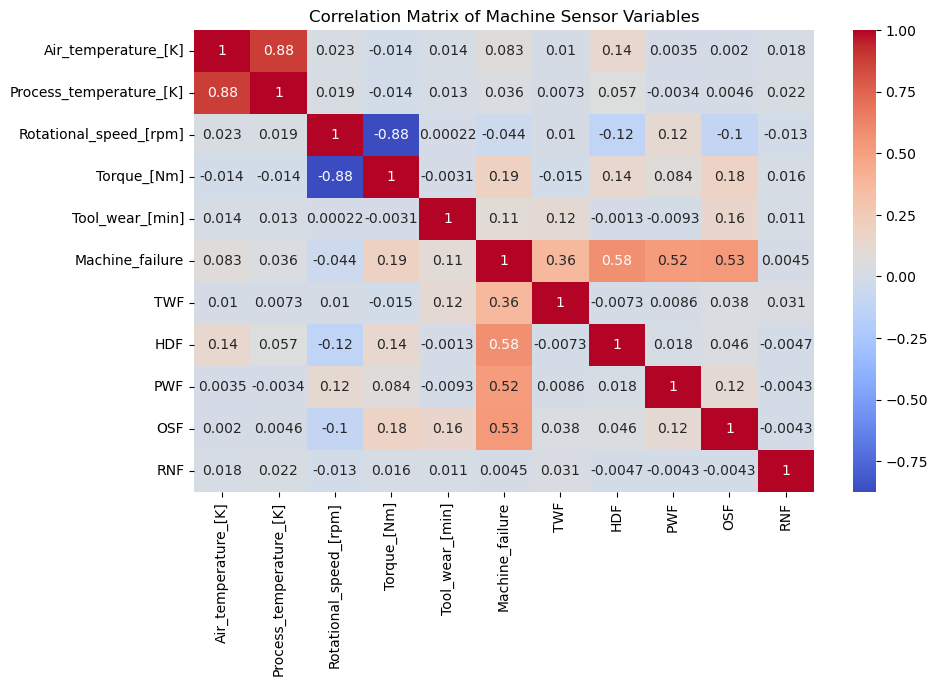

In [11]:
# Exploratory Data Analysis

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix of Machine Sensor Variables")

plt.show()

At first, a Correlation Heatmap is presented to udnerstand the relationships of the feature variables. The key findings of the Correlation Heatmap are as follows:

##### 1. Strong Relationship Between Air Temperature and Process Temperature
The heatmap shows a strong positive correlation (0.88) between air temperature and process temperature. This indicates that when the surrounding environmental temperature increases, the machine's internal process temperature also tends to increase. This is expected in manufacturing environments because machine operating conditions are influenced by ambient temperature.

##### 2. Strong Negative Relationship Between Rotational Speed and Torque
There is a strong negative correlation (-0.88) between rotational speed and torque. This suggests that machines operating at higher rotational speeds tend to generate lower torque, while machines operating at lower speeds produce higher torque, which reflects the mechanical trade-off between speed and force in rotating equipment.

##### 3. Tool Wear Shows Weak Correlation With Other Sensor Variables
Tool wear has very weak correlations with most sensor variables. This indicates that tool wear accumulates over time and not really affected by short-term operating conditions like temperature or speed.

##### 4. Machine Failure Shows Moderate Correlation With Failure Types
The variable Machine_failure shows moderate correlations with several specific failure categories:  
  • HDF (Heat Dissipation Failure): 0.58  
  • OSF (Overstrain Failure): 0.53  
  • PWF (Power Failure): 0.52  
  • TWF (Tool Wear Failure): 0.36  
These correlations indicate that machine failures are closely associated with specific operational failure modes, particularly heat dissipation and overstrain conditions.

##### 5. Machine Failure Has Weak Correlation With Sensor Variables
Machine failure has weak correlations with individual sensor measurements such as temperature, rotational speed, and torque. This suggests that machine failures are likely caused by a combination of multiple operating factors rather than a single sensor variable.

##### Operational Insights:
Overall, the heatmap suggests that while machine operating variables influence equipment behavior, machine failures are more strongly associated with specific failure mechanisms such as overheating, overstrain, or power issues. This highlights the importance of monitoring multiple indicators simultaneously when implementing predictive maintenance strategies.

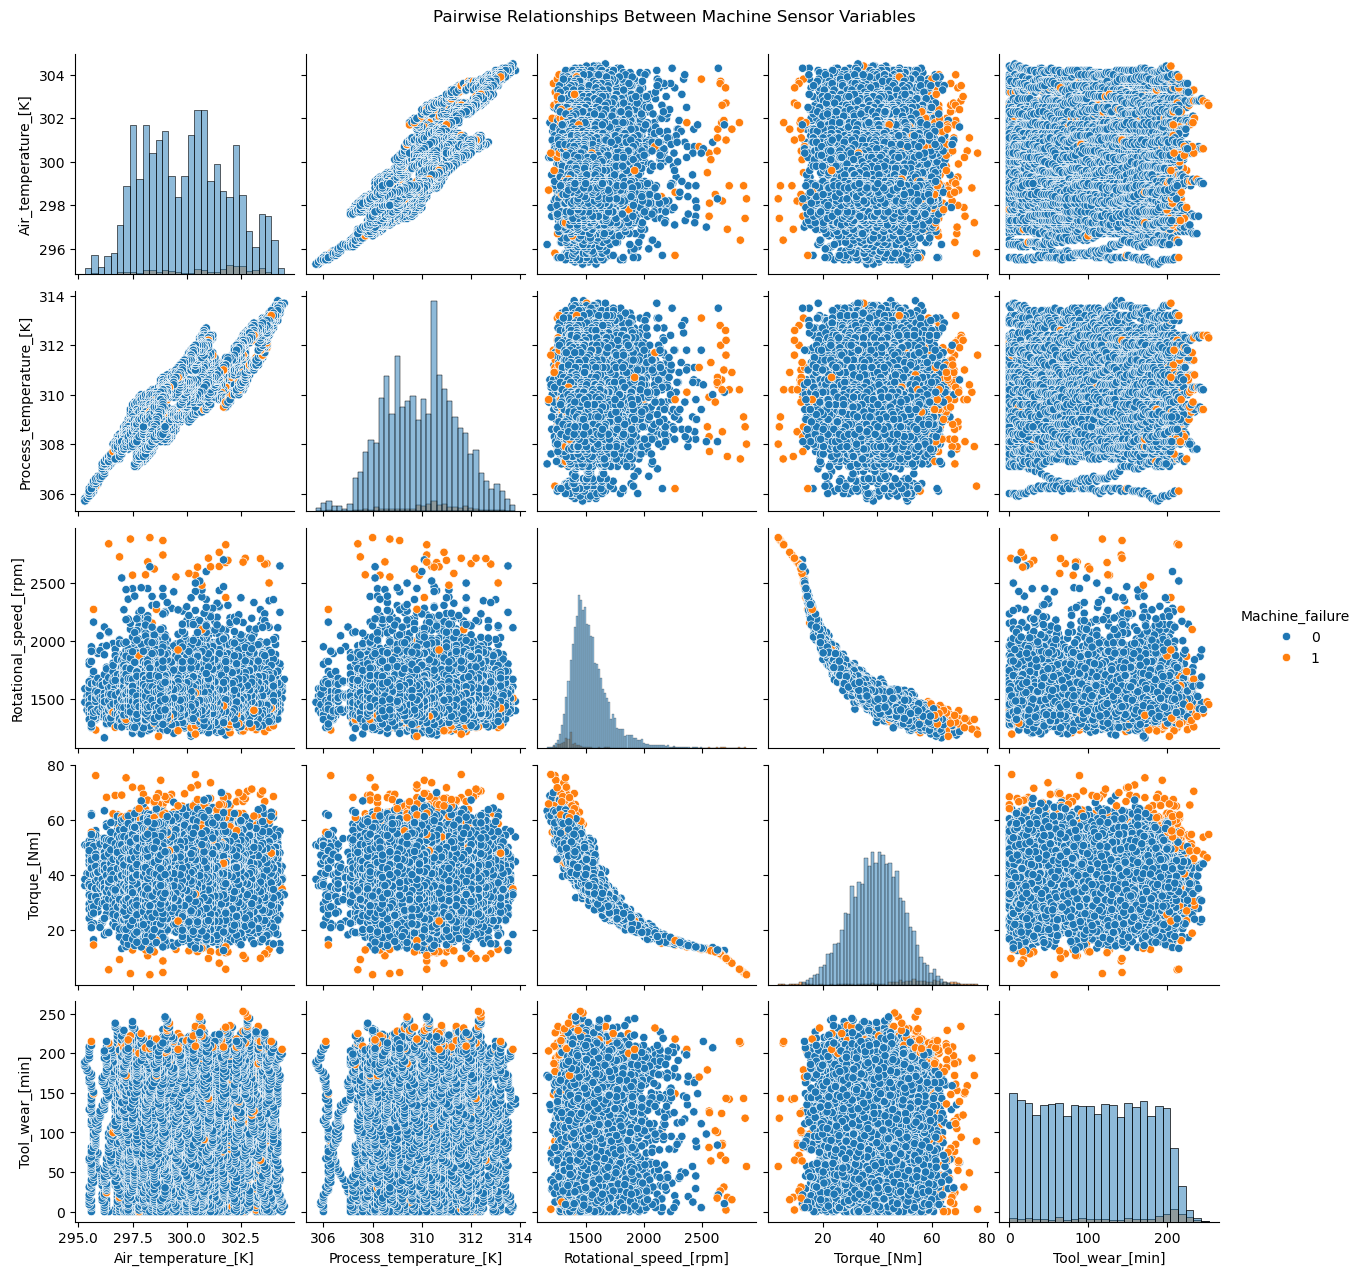

In [25]:
# Pairwise Relationships Between Key Machine Variables

pairplot_vars = [
    "Air_temperature_[K]",
    "Process_temperature_[K]",
    "Rotational_speed_[rpm]",
    "Torque_[Nm]",
    "Tool_wear_[min]",
    "Machine_failure"
]

sns.pairplot(
    df[pairplot_vars],
    hue="Machine_failure",
    diag_kind="hist"
)

plt.suptitle("Pairwise Relationships Between Machine Sensor Variables", y=1.02)

plt.show()

The pairwise plot shows the relationships among key machine sensor variables and machine failure status. A strong positive relationship is observed between air temperature and process temperature, indicating that machine internal temperature tends to increase with environmental temperature. An inverse relationship is also visible between rotational speed and torque, which reflects the typical mechanical behavior of rotating systems. Machine failures appear across different operating conditions but occur more frequently in areas with higher tool wear and certain torque ranges, suggesting that wear and mechanical stress contribute to failure.

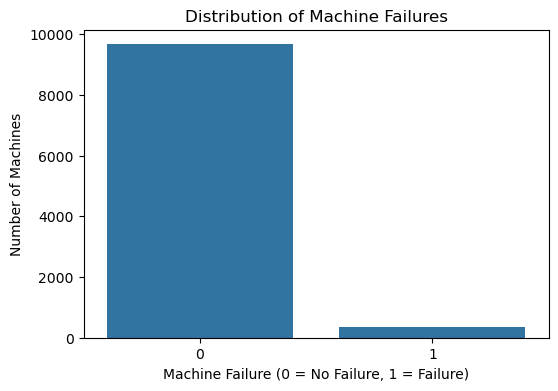

In [12]:
# Machine Failure Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Machine_failure", data=df)

plt.title("Distribution of Machine Failures")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Machines")

plt.show()

This chart enables the stakeholders to understand how frequently machine failures occur to evaluate the overall reliability of the manufacturing process. The chart shows the distribution of machines that experienced failure versus those that operated normally. The result shows that machine failures occur much less frequently than normal operations. This indicates that failure events are relatively rare within the dataset. Such imbalance is common in industrial environments where preventive maintenance practices aim to minimize equipment breakdowns.

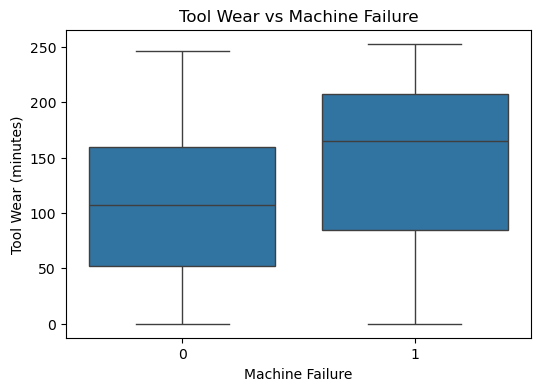

In [13]:
# Tool Wear vs Machine Failure

plt.figure(figsize=(6,4))

sns.boxplot(x="Machine_failure", y="Tool_wear_[min]", data=df)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (minutes)")

plt.show()

Tool wear is an important indicator in predictive maintenance. As machine components are used over time, wear accumulates and may increase the likelihood of equipment failure. The boxplot above compares tool wear levels between machines that failed and those that did not.  
Machines that experienced failure generally show higher tool wear values compared to machines that did not fail. This suggests that tool wear is a relevant indicator of machine condition and may contribute to increased failure risk. Monitoring tool wear can therefore help support predictive maintenance strategies.

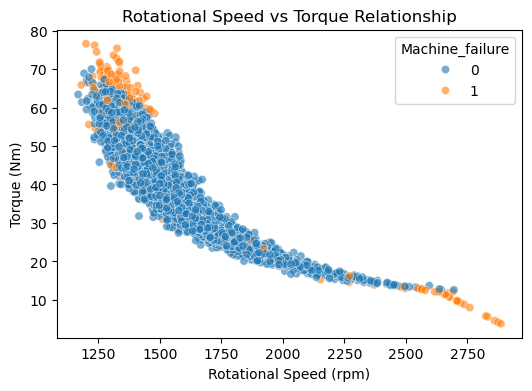

In [14]:
# Rotational Speed vs Torque Relationship

plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Rotational_speed_[rpm]",
    y="Torque_[Nm]",
    hue="Machine_failure",
    data=df,
    alpha=0.6
)

plt.title("Rotational Speed vs Torque Relationship")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")

plt.show()

Rotational speed and torque are key mechanical variables that influence machine performance. These two variables often have an inverse relationship in mechanical systems. The scatter plot illustrates the relationship between rotational speed and torque across machines. The result shows an inverse relationship between rotational speed and torque, which is consistent with mechanical system behavior. Machines operating at higher rotational speeds tend to produce lower torque, while machines with lower speeds tend to generate higher torque. This relationship was also observed in the correlation heatmap and reflects the mechanical balance between speed and force in rotating machinery.


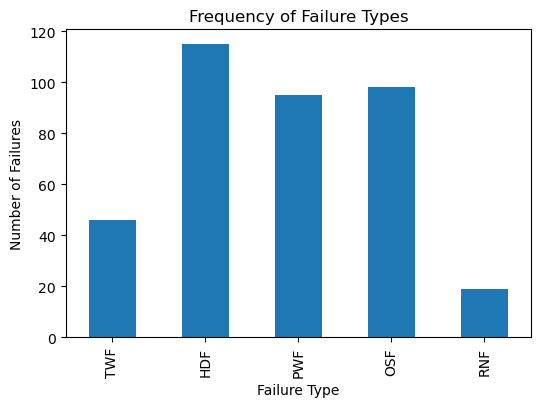

In [15]:
# Failure Type Frequency

failure_types = ["TWF","HDF","PWF","OSF","RNF"]

plt.figure(figsize=(6,4))

df[failure_types].sum().plot(kind="bar")

plt.title("Frequency of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")

plt.show()

Machine failures can occur for different reasons such as tool wear failure, heat dissipation failure, power failure, or overstrain conditions. The chart shows how frequently each type of failure occurs in the dataset. This represents the different machine failure types recorded in the dataset. Certain failure types appear more frequently than others, indicating that specific operational issues contribute more significantly to machine breakdowns. Understanding the distribution of failure types can help operations managers prioritize maintenance strategies and focus on the most common causes of equipment failure.

##### Relationship Between Air Temperature and Process Temperature

The correlation heatmap on the first visualization reveals a strong positive relationship (correlation ≈ 0.88) between air temperature and process temperature. This suggests that as the surrounding air temperature increases, the internal process temperature of the machine also tends to increase.
This relationship indicates that environmental conditions may influence machine operating temperatures. In manufacturing environments, higher ambient temperatures can reduce cooling efficiency and lead to elevated process temperatures, which may increase thermal stress on machine components.  

To provide additional context for this relationship, real-time environmental conditions are retrieved using the OpenWeatherMap API. Environmental temperature is an important factor that can influence machine air temperature and, consequently, machine process temperature. By incorporating current weather conditions into the dashboard, we can demonstrate how external environmental data may influence machine operating environments.

In [26]:
# API Component

import requests

API_KEY = "9c7bf36f5228c50f4d642ffb4f0e5d1c"

city = "Manila"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)

data = response.json()

print(data)

{'coord': {'lon': 120.9822, 'lat': 14.6042}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'base': 'stations', 'main': {'temp': 299.42, 'feels_like': 299.42, 'temp_min': 298.74, 'temp_max': 299.83, 'pressure': 1013, 'humidity': 75, 'sea_level': 1013, 'grnd_level': 1016}, 'visibility': 10000, 'wind': {'speed': 2.75, 'deg': 95, 'gust': 3.32}, 'clouds': {'all': 9}, 'dt': 1773328094, 'sys': {'type': 2, 'id': 2008256, 'country': 'PH', 'sunrise': 1773266775, 'sunset': 1773309952}, 'timezone': 28800, 'id': 1701668, 'name': 'Manila', 'cod': 200}


In [27]:
# Extract the data from API

temperature_kelvin = data["main"]["temp"]
humidity = data["main"]["humidity"]
pressure = data["main"]["pressure"]

weather_condition = data["weather"][0]["description"]

temperature_celsius = temperature_kelvin - 273.15

print("City:", city)
print("Temperature:", round(temperature_celsius,2), "°C")
print("Humidity:", humidity, "%")
print("Pressure:", pressure, "hPa")
print("Weather:", weather_condition)

City: Manila
Temperature: 26.27 °C
Humidity: 75 %
Pressure: 1013 hPa
Weather: clear sky


In [18]:
# Convert API into dataframe

import pandas as pd

weather_df = pd.DataFrame({
    "City":[city],
    "Temperature_C":[round(temperature_celsius,2)],
    "Humidity":[humidity],
    "Pressure":[pressure],
    "Weather":[weather_condition]
})

weather_df

,City,Temperature_C,Humidity,Pressure,Weather
0,Manila,26.73,72,1013,scattered clouds


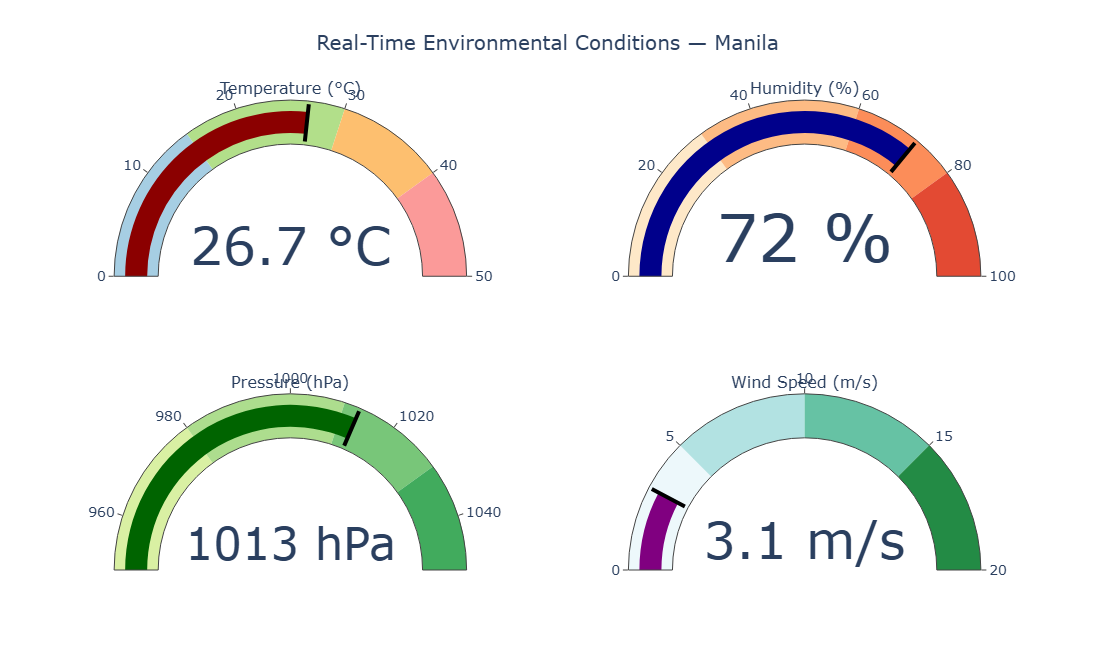

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Convert temperature (if API returned Kelvin)
temperature_celsius = round(data["main"]["temp"] - 273.15, 1)
humidity = round(data["main"]["humidity"], 1)
pressure = round(data["main"]["pressure"], 1)
wind_speed = round(data["wind"]["speed"], 1)

fig = make_subplots(
    rows=2,
    cols=2,
    specs=[[{'type':'indicator'}, {'type':'indicator'}],
           [{'type':'indicator'}, {'type':'indicator'}]],
    subplot_titles=("Temperature (°C)", "Humidity (%)",
                    "Pressure (hPa)", "Wind Speed (m/s)")
)

# Temperature Gauge
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=temperature_celsius,
    number={'suffix': " °C"},
    gauge={
        'axis': {'range': [0,50]},
        'bar': {'color': "darkred"},
        'steps': [
            {'range': [0,15], 'color': "#a6cee3"},
            {'range': [15,30], 'color': "#b2df8a"},
            {'range': [30,40], 'color': "#fdbf6f"},
            {'range': [40,50], 'color': "#fb9a99"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'value': temperature_celsius
        }
    }
), row=1, col=1)

# Humidity Gauge
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=humidity,
    number={'suffix': " %"},
    gauge={
        'axis': {'range': [0,100]},
        'bar': {'color': "darkblue"},
        'steps': [
            {'range': [0,30], 'color': "#fee8c8"},
            {'range': [30,60], 'color': "#fdbb84"},
            {'range': [60,80], 'color': "#fc8d59"},
            {'range': [80,100], 'color': "#e34a33"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'value': humidity
        }
    }
), row=1, col=2)

# Pressure Gauge
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=pressure,
    number={'suffix': " hPa"},
    gauge={
        'axis': {'range': [950,1050]},
        'bar': {'color': "darkgreen"},
        'steps': [
            {'range': [950,980], 'color': "#d9f0a3"},
            {'range': [980,1010], 'color': "#addd8e"},
            {'range': [1010,1030], 'color': "#78c679"},
            {'range': [1030,1050], 'color': "#41ab5d"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'value': pressure
        }
    }
), row=2, col=1)

# Wind Speed Gauge
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=wind_speed,
    number={'suffix': " m/s"},
    gauge={
        'axis': {'range': [0,20]},
        'bar': {'color': "purple"},
        'steps': [
            {'range': [0,5], 'color': "#edf8fb"},
            {'range': [5,10], 'color': "#b2e2e2"},
            {'range': [10,15], 'color': "#66c2a4"},
            {'range': [15,20], 'color': "#238b45"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'value': wind_speed
        }
    }
), row=2, col=2)

fig.update_layout(
    title={
        "text": "Real-Time Environmental Conditions — Manila",
        "x": 0.5,
        "xanchor": "center"
    },
    height=650,
    template="plotly_white",
    font=dict(size=14)
)

fig.show()

### Interpretation of Environmental Dashboard

The gauges display the current environmental conditions in Manila obtained through the OpenWeatherMap API, including temperature, humidity, atmospheric pressure, and wind speed. These metrics provide contextual information about the operating environment in which manufacturing machines may function.

Temperature is particularly relevant to the earlier analysis of the machine dataset. The correlation heatmap revealed a strong positive relationship (≈0.88) between machine air temperature and process temperature. This indicates that changes in surrounding air temperature are associated with changes in internal process temperature during machine operation.

The current environmental temperature shown in the dashboard represents the ambient conditions that may influence machine air temperature. If environmental temperatures rise, machine air temperatures may also increase, potentially leading to higher process temperatures and increased thermal stress on machine components.

Humidity and wind speed may also affect airflow and cooling efficiency in manufacturing facilities, while atmospheric pressure reflects general environmental stability. Although the dataset itself contains internal machine sensor measurements, integrating external environmental conditions demonstrates how predictive maintenance dashboards can combine machine data with environmental context to better understand operational risks and machine behavior.